In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import warnings 
warnings.filterwarnings("ignore") #ignore some matplotlib warnings

import numpy as np

from mpi4py import MPI

from triqs.plot.mpl_interface import plt, oplot, oplotr, oploti
plt.rcParams["figure.figsize"] = (6,4) # set default size for all figures

# Step-by-step guide

## Step 1 - Impurity many-body Hamiltonian

First we have to construct the local many-body Hamiltonian (`H_loc`) of the Anderson impurity model we want to solve.

### Examples

- For the **single band Hubbard model** the interaction is density-density only and can be constructed using the Triqs second-quantization operators found in `triqs.operators.*`.

In [2]:
from triqs.operators import n

U = 2.0
mu = U / 2 # Chemical potential for half-filling

N_tot = n('up', 0) + n('do', 0) # Total density operator

H_loc = U * n('up',0) * n('do', 0) - mu * N_tot

print(H_loc)

-1*c_dag('do',0)*c('do',0) + -1*c_dag('up',0)*c('up',0) + 2*c_dag('do',0)*c_dag('up',0)*c('up',0)*c('do',0)


- For multi-orbital models one often use the **Kanamori interaction** which can be built using tools in `triqs.operators.util.*` as follows.

In [3]:
norb = 3
spin_names = ['up', 'do']

U = 4.6
J = 0.8

from triqs.operators.util.U_matrix import U_matrix_kanamori

KanMat1, KanMat2 = U_matrix_kanamori(norb, U, J)

from triqs.operators.util.hamiltonians import h_int_kanamori

H_int_3 = h_int_kanamori(spin_names, norb, KanMat1, KanMat2, J, off_diag=True)

from itertools import product
N_tot_3 = sum([ n(spin, idx) for spin, idx in product(spin_names, range(norb)) ])

mu = 0.5*(5*U - 10*J)

H_loc_3 = H_int_3 - mu * N_tot_3

print(H_loc_3)

-7.5*c_dag('do',0)*c('do',0) + -7.5*c_dag('do',1)*c('do',1) + -7.5*c_dag('do',2)*c('do',2) + -7.5*c_dag('up',0)*c('up',0) + -7.5*c_dag('up',1)*c('up',1) + -7.5*c_dag('up',2)*c('up',2) + 2.2*c_dag('do',0)*c_dag('do',1)*c('do',1)*c('do',0) + 2.2*c_dag('do',0)*c_dag('do',2)*c('do',2)*c('do',0) + 0.8*c_dag('do',0)*c_dag('up',0)*c('up',2)*c('do',2) + 0.8*c_dag('do',0)*c_dag('up',0)*c('up',1)*c('do',1) + 4.6*c_dag('do',0)*c_dag('up',0)*c('up',0)*c('do',0) + 3*c_dag('do',0)*c_dag('up',1)*c('up',1)*c('do',0) + 0.8*c_dag('do',0)*c_dag('up',1)*c('up',0)*c('do',1) + 3*c_dag('do',0)*c_dag('up',2)*c('up',2)*c('do',0) + 0.8*c_dag('do',0)*c_dag('up',2)*c('up',0)*c('do',2) + 2.2*c_dag('do',1)*c_dag('do',2)*c('do',2)*c('do',1) + 0.8*c_dag('do',1)*c_dag('up',0)*c('up',1)*c('do',0) + 3*c_dag('do',1)*c_dag('up',0)*c('up',0)*c('do',1) + 0.8*c_dag('do',1)*c_dag('up',1)*c('up',2)*c('do',2) + 4.6*c_dag('do',1)*c_dag('up',1)*c('up',1)*c('do',1) + 0.8*c_dag('do',1)*c_dag('up',1)*c('up',0)*c('do',0) + 3*c_dag('d

## Step 2 - Spawn solver instance

The second step in using `xca` is to instantiate an instance of the `triqs_xca.BlockSparseSolver` class.

In [4]:
from triqs_xca import BlockSparseSolver as Solver

norb = 1

S = Solver(
    H_loc=H_loc,
    beta=5.0, 
    w_max=50.0,
    eps=1e-8, 
    gf_struct=[('up', norb), ('do', norb)], 
    )

Starting run with 1 MPI rank(s) at : 2026-05-18 14:34:40.806043


____  ____________     _____
\   \/  /\_   ___ \   /  _  \
 \     / /    \  \/  /  /_\  \
 /     \ \     \____/    |    \
/___/\  \ \______  /\____|__  /
      \_/        \/         \/  [github.com/TRIQS/xca]

beta = 5.0, w_max = 50.0, eps = 1e-08, N_DLR = 32
AtomDiagReal: dim 4 with 4 subspaces dims [1] freq [4] E min/max +0.00E+00/+1.00E+00


The solver constructor takes the input

- `H_loc` : Impurity local Hamiltonian
- `beta`: Inverse temperature
- `w_max`: DLR frequency cut-off (the spectrum of the model must be in the range `[-w_max, +w_max]`
- `eps`: Accuracy of Discrete Lehmann Representation (DLR) used for imaginary time response functions
- `gf_struct`: Green's function structure 1st index: name, 2nd index: dimension of subspace

### Using atomic symmetries

The solver takes the optional parameter `conserved_operators` which defaults to `automatic`. This will automatically use the full set of state permutation symmetries that block diagonalizes the local Hamiltonian `H_loc`.

**Note** for multiorbital systems it can be faster to use only a subset of symmetries, like total density, by setting `conserved_operators=[N_tot]`, where `N_tot` is the total density operator (using Triqs 2nd quantization operators), i.e. `N_tot = sum([n('up', oidx) + n('do', oidx) for oidx in range(norb)])`.

(To disable the use of symmetries simply pass `conserved_operators=[]`.)

## Step 3 - Hybridization function

To fully specify the Anderson impurity model we also have to supply the hybridization function $\Delta(\tau)$ that describes the retarded fluctuation of electrons to the environment. The solver instance `S` sets up the hybridization function container available as `S.Delta_tau` and we need to explicitly set its value.

### Examples

Here is a simple example with a Hybridization function $\Delta(\tau)$ comprised of a **single discrete pole/state**.

In [5]:
from triqs.gf import make_gf_dlr_imtime, make_gf_dlr_imfreq
from triqs.gf import inverse, iOmega_n

for bidx, delta_tau in S.Delta_tau:
    delta_w = make_gf_dlr_imfreq(delta_tau)
    delta_w << inverse(iOmega_n - 1.0)
    delta_tau[:] = make_gf_dlr_imtime(delta_w)

Another common test case is a spin- and orbital-diagonal hybridzation function with a **semi-circular density of states**.

In [6]:
from triqs.gf import make_gf_dlr_imtime, make_gf_dlr_imfreq, SemiCircular

for bidx, delta_tau in S.Delta_tau:
    delta_w = make_gf_dlr_imfreq(delta_tau)
    delta_w << SemiCircular(2.0)
    delta_tau[:] = make_gf_dlr_imtime(delta_w)

## Step 4 - Self-consistent solution

Combining the hybridization function `S.Delta_tau` and the local many-body interaction `h_int` the Anderson impurity model is fully specified and we can call the `S.solve(...)` method to obtain the pseudo-particle self-consistent solution at a given expansion `order`.

In [7]:
S.solve(max_order=2, verbose=True)

AAA: Error 1.87E-01 using 1 support and 30 fitting points (step 1/31)
AAA: Error 6.16E-04 using 2 support and 28 fitting points (step 2/31)
AAA: Error 2.40E-07 using 3 support and 26 fitting points (step 3/31)
AAA: Converged after 3 steps with error 2.40E-07.
TDC: Error 7.49E-07 for 3 AAA steps (Error 6.16E-04 no opt) c.f. tol 1.00E-05.
AAA: Error 1.87E-01 using 1 support and 30 fitting points (step 1/1)
TDC: Error 2.70E-01 for 1 AAA steps (Error 7.34E-01 no opt) c.f. tol 1.00E-05.
AAA: Error 1.87E-01 using 1 support and 30 fitting points (step 1/2)
AAA: Error 6.16E-04 using 2 support and 28 fitting points (step 2/2)
TDC: Error 1.58E-03 for 2 AAA steps (Error 1.87E-01 no opt) c.f. tol 1.00E-05.
TDC: Compression finished with 3 AAA steps and error 7.49E-07.
Adapol: Fit error = 7.49E-07 < tol_adapol = 1.00E-05, N_poles = 5
iter = 1, diff_G = 1.79E-01, Z-1 = -1.65E-10, eta = 5.14E-01
iter = 2, diff_G = 1.25E-01, Z-1 = -9.58E-11, eta = 6.81E-01
iter = 3, diff_G = 3.70E-02, Z-1 = -2.49E-11,

### Hybridization compression

For `max_order > 1` the solver will by default try to compress the hybridization function using [Adapol](https://github.com/flatironinstitute/adapol) to a minimal set of poles. The fit tolerance `hyb_tol` defaults to `100*eps` but can be passed as an optional argument to the `solve(...)` function.

It is also possible to turn off the compression entirely by passing `hyb_comp=False` which will cause the solver to use the (larger) DLR pole representation, i.e.

In [8]:
S.solve(max_order=2, verbose=True, hyb_comp=False)

Adapol: Fit error = 1.00E-08 < tol_adapol = 1.00E-05, N_poles = 32
iter = 1, diff_G = 1.06E-04, Z-1 = -2.53E-14, eta = 7.32E-01
iter = 2, diff_G = 1.03E-05, Z-1 = +1.42E-14, eta = 7.32E-01
Converged after 2 iterations with diff_G = 1.03E-05 < tol = 1.00E-04

Timing:                       incl.     excl.
----------------------------------------------------
Adapol hybridization fit:     0.007     0.007   2.1% ||
AtomDiag Init:                0.000     0.000   0.0% |
DiagramEvaluator Init:        0.000     0.000   0.1% |
Dyson:                        0.021     0.001   0.3% |
 Setup:                       0.015     0.015   4.2% |-|
 Solve:                       0.005     0.005   1.4% ||
Sigma:                        0.236     0.000   0.1% |
 Order 1:                     0.003     0.003   0.7% |
 Order 2:                     0.233     0.233  65.8% |-------------------------|
Single-particle Gf:           0.062     0.000   0.0% |
 Order 1:                     0.000     0.000   0.1% |
 Order 

## Step 5 - Single particle response function

After convergence the solver computes the diagrammatic series for the single particle Green's function that is available as the member `S.G_tau` of the solver class instance `S`.

In [9]:
print(S.G_tau)

Green Function G composed of 2 blocks: 
 Green's Function G_up with mesh DLR imaginary time mesh of size 32 with beta = 5, statistics = Fermion, w_max = 50, eps = 1e-08, symmetrized = false and target_shape (1, 1): 
 
 Green's Function G_do with mesh DLR imaginary time mesh of size 32 with beta = 5, statistics = Fermion, w_max = 50, eps = 1e-08, symmetrized = false and target_shape (1, 1): 
 



## Step 6 - Store solver to disk

The solver is hdf5 serializable and can be written to disk using the `h5` module.

In [10]:
from h5 import HDFArchive

filename = f'data_xca_result.h5'
with HDFArchive(filename, 'w') as A: 
    A['S'] = S

## Step 7 - Read result from disk

For later visualization we can now read the solver and its data from disk.

In [11]:
with HDFArchive(filename, 'r') as A:
        S = A['S']

## Step 7 - Postprocessing and visualization 

The single particle Green's function can now be visualized using the standard Triqs plotting tools.

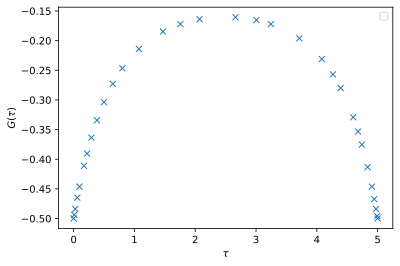

In [12]:
from triqs.plot.mpl_interface import plt, oplot, oplotr, oploti

oplotr(S.G_tau['up'][0, 0], label=None)
plt.ylabel(r'$G(\tau)$');